In [112]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd
import tensorflow as tf

In [113]:
dataset = pd.read_csv(r"C:\Users\Manish\Desktop\diabetes.csv")

In [114]:
x = dataset.iloc[:,0:-1].values
y = dataset.iloc[:,-1].values


In [115]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 0)

In [116]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test) 

In [117]:
ann = tf.keras.models.Sequential()
ann.add(tf.keras.layers.Dense(units=10, activation = 'relu'))
ann.add(tf.keras.layers.Dense(units=10, activation = 'relu'))
ann.add(tf.keras.layers.Dense(units=10, activation = 'relu'))
#ann.add(tf.keras.layers.Dense(units=10, activation = 'relu'))
ann.add(tf.keras.layers.Dense(units=1, activation = 'sigmoid'))

In [118]:
ann.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [119]:
history  = ann.fit(X_train,y_train,batch_size= 30,epochs= 100)

Epoch 1/100
21/21 [==============================] - 1s 3ms/step - loss: 0.6561 - accuracy: 0.6616
Epoch 2/100
21/21 [==============================] - 0s 3ms/step - loss: 0.6327 - accuracy: 0.6387
Epoch 3/100
21/21 [==============================] - 0s 4ms/step - loss: 0.6135 - accuracy: 0.6552
Epoch 4/100
21/21 [==============================] - 0s 3ms/step - loss: 0.5819 - accuracy: 0.6618
Epoch 5/100
21/21 [==============================] - 0s 4ms/step - loss: 0.5491 - accuracy: 0.7013
Epoch 6/100
21/21 [==============================] - 0s 4ms/step - loss: 0.5440 - accuracy: 0.7084
Epoch 7/100
21/21 [==============================] - 0s 4ms/step - loss: 0.5221 - accuracy: 0.7295
Epoch 8/100
21/21 [==============================] - 0s 4ms/step - loss: 0.5366 - accuracy: 0.7203
Epoch 9/100
21/21 [==============================] - 0s 4ms/step - loss: 0.5080 - accuracy: 0.7586
Epoch 10/100
21/21 [==============================] - 0s 3ms/step - loss: 0.5207 - accuracy: 0.7335
Epoch 11/

In [120]:
#lets predict if a person with 0 pregnancies, 150 glucose, 121 blood pressure, 12 skin thickness, 98 insulin, 28 BMI, 0.254 diabetes pedigree function, 17 years of age  will have diabetes or not
print( ann.predict(sc.transform([[6,148,72,35,0,33.6,0.627,50]])) > 0.5 )

[[ True]]


In [121]:
#so the person with above biodata will not have diabetes
y_pred = ann.predict(X_test)
y_pred = (y_pred > 0.5)
print(np.concatenate((y_pred.reshape(len(y_pred),1),y_test.reshape(len(y_test),1)),1))

[[1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 1]
 [1 1]
 [0 1]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 1]
 [1 1]
 [1 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [1 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [1 0]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [1 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]

In [122]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_pred,y_test)
print(cm)
accuracy_score(y_pred,y_test)

[[88 12]
 [19 35]]


0.7987012987012987

In [123]:
print(history.history.keys())

dict_keys(['loss', 'accuracy'])


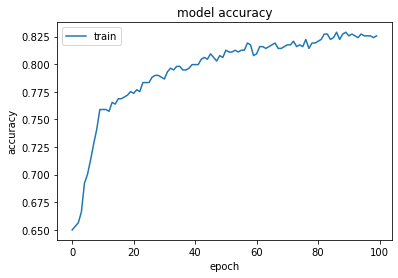

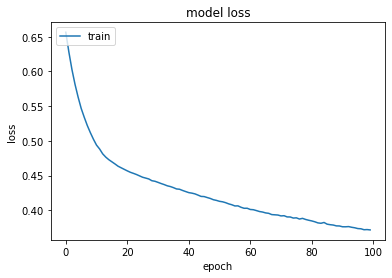

In [126]:
plt.plot(history.history['accuracy'])
#plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
#plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()